# FEATURE ENGINEERING AND RECOMMENDATION ENGINE
## 1. Load Cleaned Data
### Load the Master Tracks Table
Import pandas, numpy, and the scaling tools needed for feature engineering,then load the merged `Tracks_summary.csv` produced by the data-cleaning notebook — this single table is the foundation for the whole recommendation engine.

In [ ]:
# Load Cleaned Data
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


tracks_df = pd.read_csv(r"Data/Cleaned/Tracks_summary.csv")
tracks_df.columns
tracks_df.head()

,track_key,artist_name,track_name,play_count,total_minutes_played,first_played,last_played,playlist_count,playlists,in_library
0,(((()))) - novacane - 8d audio,(((()))),Novacane - 8D Audio,2,1.063917,2026-01-12 05:25:00,2026-02-11 08:05:00,0,Not in any playlist,True
1,03’babyshay - dreamz & nightmarez - wthelly?,03’BabyShay,Dreamz & NightMarez - Wthelly?,1,0.032167,2026-04-23 20:13:00,2026-04-23 20:13:00,0,Not in any playlist,False
2,5 seconds of summer - youngblood,5 Seconds of Summer,Youngblood,9,30.512617,2025-07-21 07:39:00,2026-02-13 16:09:00,1,Life,True
3,50 cent - baby by me,50 Cent,Baby By Me,7,16.763717,2026-03-13 05:50:00,2026-06-16 11:15:00,1,R&B,True
4,50 cent - just a lil bit,50 Cent,Just A Lil Bit,7,8.813900,2026-03-13 05:56:00,2026-06-16 12:16:00,1,"Volume up ,logic down",False


## 2. Feature engineering
### Engineer Recency and Artist-Level Features
Convert the play-date columns to datetimes, then derive new features:`days_since_last_play` (recency), `listening_weeks` and `plays_per_week`(listening consistency) and artist-level totals(`artist_play_count`,
`artist_total_minutes`) that capture how much the user listens to a track's artist overall, not just the track itself.

In [54]:
# Feature engineering
#Convert dates
tracks_df["first_played"] = pd.to_datetime(tracks_df["first_played"])
tracks_df["last_played"] = pd.to_datetime(tracks_df["last_played"])

# Recency
reference_date = tracks_df["last_played"].max()

tracks_df["days_since_last_play"] = (
    reference_date - tracks_df["last_played"]
).dt.days

# Listening consistency
tracks_df["listening_weeks"] = (
    (tracks_df["last_played"] - tracks_df["first_played"]).dt.days / 7
)

tracks_df["listening_weeks"] = tracks_df["listening_weeks"].clip(lower=1)

# Average plays per week
tracks_df["plays_per_week"] = (
    tracks_df["play_count"] /
    tracks_df["listening_weeks"]
)

# Favorite artist score
tracks_df["artist_play_count"] = (
    tracks_df.groupby("artist_name")["play_count"]
             .transform("sum")
)

tracks_df["artist_total_minutes"] = (
    tracks_df.groupby("artist_name")["total_minutes_played"]
             .transform("sum")
)


tracks_df.head()

,track_key,artist_name,track_name,play_count,total_minutes_played,first_played,last_played,playlist_count,playlists,in_library,days_since_last_play,listening_weeks,plays_per_week,artist_play_count,artist_total_minutes
0,(((()))) - novacane - 8d audio,(((()))),Novacane - 8D Audio,2,1.063917,2026-01-12 05:25:00,2026-02-11 08:05:00,0,Not in any playlist,True,129.0,4.285714,0.466667,2.0,1.063917
1,03’babyshay - dreamz & nightmarez - wthelly?,03’BabyShay,Dreamz & NightMarez - Wthelly?,1,0.032167,2026-04-23 20:13:00,2026-04-23 20:13:00,0,Not in any playlist,False,57.0,1.000000,1.000000,1.0,0.032167
2,5 seconds of summer - youngblood,5 Seconds of Summer,Youngblood,9,30.512617,2025-07-21 07:39:00,2026-02-13 16:09:00,1,Life,True,127.0,29.571429,0.304348,9.0,30.512617
3,50 cent - baby by me,50 Cent,Baby By Me,7,16.763717,2026-03-13 05:50:00,2026-06-16 11:15:00,1,R&B,True,4.0,13.571429,0.515789,14.0,25.577617
4,50 cent - just a lil bit,50 Cent,Just A Lil Bit,7,8.813900,2026-03-13 05:56:00,2026-06-16 12:16:00,1,"Volume up ,logic down",False,4.0,13.571429,0.515789,14.0,25.577617


## 3. Normalization
### Normalize Features and Compute a Preference Score
- Scale the raw numeric features to a 0–1 range with `MinMaxScaler`, convert recency into a `recency_score` (higher = more recently played), and combine everything into a single weighted `preference_score` (play count, minutes played, playlist count, recency, and library status).
- Fill any remaining gaps with 0, then standardize the final feature set with `StandardScaler` to produce the matrix `X` that the similarity model will use.

In [55]:
# Normalization
# Normalize numericalfeatures

numeric_cols = [
    "play_count",
    "total_minutes_played",
    "artist_play_count",
    "artist_total_minutes",
    "plays_per_week"
]

scaler = MinMaxScaler()

tracks_df[numeric_cols] = scaler.fit_transform(
    tracks_df[numeric_cols]
)

# Normalize recency
tracks_df["recency_score"] = 1 - (
    tracks_df["days_since_last_play"] /
    tracks_df["days_since_last_play"].max()
)

# Preferance score
tracks_df["preference_score"] = (
      0.35 * tracks_df["play_count"]
    + 0.25 * tracks_df["total_minutes_played"]
    + 0.15 * tracks_df["playlist_count"]
    + 0.15 * tracks_df["recency_score"]
    + 0.10 * tracks_df["in_library"]
)

#Final feature matrix
features = [
    "play_count",
    "total_minutes_played",
    "playlist_count",
    "in_library",
    "artist_play_count",
    "artist_total_minutes",
    "plays_per_week",
    "recency_score",
    "preference_score"
]

print(tracks_df[features].isna().sum())
# Fill NaNs with 0 for engineered features
tracks_df[["artist_play_count", "artist_total_minutes",
           "plays_per_week", "recency_score", "preference_score"]] = (
    tracks_df[["artist_play_count", "artist_total_minutes",
               "plays_per_week", "recency_score", "preference_score"]].fillna(0)
)

# Scale features
scaler = StandardScaler()

X = scaler.fit_transform(tracks_df[features])

play_count               0
total_minutes_played     0
playlist_count           0
in_library               0
artist_play_count       66
artist_total_minutes    66
plays_per_week          66
recency_score           66
preference_score        66
dtype: int64


## 4. Baseline Recommendation Engine
### Baseline: Popularity-Based Recommendations
Before building the similarity-based engine, establish a simple baseline by sorting all tracks by `preference_score` and viewing the top 10 — this gives something to compare the smarter, content-based recommendations against later.

In [56]:
# Baseline Recommendation Engine

# Sort songs by preference score
popularity_recommendations = (
    tracks_df
    .sort_values(by="preference_score", ascending=False)
    .reset_index(drop=True)
)

# Display the top 10 songs
popularity_recommendations[
    [
        "track_name",
        "artist_name",
        "preference_score",
        "play_count"
    ]
].head(10)

,track_name,artist_name,preference_score,play_count
0,double take,Dhruv,1.394369,0.777778
1,Come Through (feat. Chris Brown),H.E.R.,1.269207,0.911111
2,"One Of The Girls (with JENNIE, Lily Rose Depp)",The Weeknd,1.244425,1.000000
3,Please Me,Cardi B,1.203845,0.733333
4,lowkey,NIKI,1.100010,0.866667
5,Bad Girls Like You,Tobii,1.084840,0.511111
6,Swim,Chase Atlantic,1.081381,0.488889
7,Good For You,Selena Gomez,1.069968,0.466667
8,Into You,Ariana Grande,1.049062,0.688889
9,Like I'm Gonna Lose You (feat. John Legend),Meghan Trainor,1.036979,0.466667


## 5. Build the Cosine Similarity Matrix
Compute the pairwise cosine similarity between every track's feature vector in `X`. The result is a square matrix where each cell represents how "similar" two tracks are based on listening behavior and artist patterns — this is the core of the content-based engine.

In [57]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute the similarity matrix
similarity_matrix = cosine_similarity(X)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (2205, 2205)


## 6. Create a DataFrame for the similarity matrix
### Inspect the Similarity Matrix
Wrap the raw similarity matrix in a labeled DataFrame (using `track_key` as both row and column labels) so individual similarity scores between named tracks can be inspected directly, and preview the first 5x5 corner.

In [58]:
# Create a DataFrame for the similarity matrix
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=tracks_df["track_key"],
    columns=tracks_df["track_key"]
)

similarity_df.iloc[:5, :5]

track_key,(((()))) - novacane - 8d audio,03’babyshay - dreamz & nightmarez - wthelly?,5 seconds of summer - youngblood,50 cent - baby by me,50 cent - just a lil bit
track_key,,,,,
(((()))) - novacane - 8d audio,1.000000,0.094714,0.600583,0.661724,-0.162420
03’babyshay - dreamz & nightmarez - wthelly?,0.094714,1.000000,-0.511756,-0.267318,0.077537
5 seconds of summer - youngblood,0.600583,-0.511756,1.000000,0.909268,0.281177
50 cent - baby by me,0.661724,-0.267318,0.909268,1.000000,0.445366
50 cent - just a lil bit,-0.162420,0.077537,0.281177,0.445366,1.000000


## 7. Create a lookup dictionary
### Build a Track-Key-to-Row-Index Lookup
Create a lookup so that given a `track_key` (e.g. `"artist - song"`), the corresponding row/column position in the similarity matrix can be found quickly — this is what makes it possible to recommend by song name rather than by row number.

In [59]:

# Create a lookup dictionary

track_lookup = pd.Series(
    data=tracks_df.index,
    index=tracks_df["track_key"]
).drop_duplicates()

track_lookup.head()

track_key
(((()))) - novacane - 8d audio                  0
03’babyshay - dreamz & nightmarez - wthelly?    1
5 seconds of summer - youngblood                2
50 cent - baby by me                            3
50 cent - just a lil bit                        4
dtype: int64

## 8. Recommendation Function
### Define the Core Recommendation Function
Write `recommend_songs()`, which takes a seed track, looks up its position in the similarity matrix,ranks every other track by similarity score,drops the seed track itself and returns the top N most similar tracks along with their preference score, play count and other context.

In [60]:
# Recommendation Function

def recommend_songs(track_key, similarity_matrix, tracks_df, track_lookup, top_n=10):
    """
    Recommend songs similar to a selected track using cosine similarity.

    Parameters
    ----------
    track_key : str
        Unique track identifier (artist - song).
    similarity_matrix : numpy.ndarray
        Matrix containing cosine similarity scores.
    tracks_df : pandas.DataFrame
        Dataset containing all tracks.
    track_lookup : pandas.Series
        Maps track_key to DataFrame index.
    top_n : int
        Number of recommendations to return.

    Returns
    -------
    pandas.DataFrame
        Top N recommended songs.
    """

    # Check whether the song exists
    if track_key not in track_lookup.index:
        print(f"'{track_key}' not found in the dataset.")
        return None

    # Find row number
    idx = track_lookup[track_key]

    # Retrieve similarity scores
    similarity_scores = list(enumerate(similarity_matrix[idx]))

    # Sort scores from highest to lowest
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected song itself
    similarity_scores = similarity_scores[1:top_n+1]

    # Retrieve indices
    recommended_indices = [i[0] for i in similarity_scores]

    # Create recommendations DataFrame
    recommendations = tracks_df.iloc[recommended_indices].copy()

    # Add similarity scores
    recommendations["similarity_score"] = [
        score for _, score in similarity_scores
    ]

    return recommendations[
        [
            "track_name",
            "artist_name",
            "similarity_score",
            "preference_score",
            "play_count",
            "total_minutes_played",
            "playlist_count",
            "in_library"
        ]
    ]

## 9. Test the recommendation function
### Sample Some Track Keys to Test With
Pull a random sample of `track_key` values from the dataset to use as example seed songs for testing the recommendation function below.

In [61]:
# Test the recommendation function
tracks_df["track_key"].sample(10, random_state=42)

1966                           taylor swift - paper rings
1091                              katy perry - wide awake
1468                                  njerae - beg for it
438                                  chase atlantic - her
1790    sean paul - (when you gonna) give it up to me ...
1953                                taylor swift - august
752                      elite subliminals - perfect nose
408                              charlie puth - attention
1477                  normani - wild side (feat. cardi b)
2037                     tommee profitt - forbidden fruit
Name: track_key, dtype: str

### Test on a Single Seed Track
Run the recommendation function on one specific track ("chase atlantic - her") to sanity-check that it returns sensible, similar songs.

In [62]:
recommend_songs(
    "chase atlantic - her",
    similarity_matrix,
    tracks_df,
    track_lookup
)

,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
477,TOO LATE,Chase Atlantic,0.999956,0.259574,0.022222,0.013230,1,False
433,Falling,Chase Atlantic,0.999503,0.257633,0.022222,0.015354,1,False
420,Church,Chase Atlantic,0.999295,0.263346,0.022222,0.015131,1,False
413,ALEYUH,Chase Atlantic,0.997024,0.267806,0.022222,0.013190,1,False
478,Triggered,Chase Atlantic,0.995795,0.265130,0.022222,0.002487,1,False
453,No Friends (feat. ILOVEMAKONNEN & K Camp),Chase Atlantic,0.992281,0.273287,0.022222,0.015332,1,False
444,INTRO,Chase Atlantic,0.990671,0.273208,0.022222,0.008423,1,False
460,OUT THE ROOF,Chase Atlantic,0.990596,0.274470,0.022222,0.013474,1,False
451,MOLLY,Chase Atlantic,0.990498,0.274680,0.022222,0.014314,1,False
454,NO RAINBOWS,Chase Atlantic,0.990436,0.274793,0.022222,0.014765,1,False


### Test Across Multiple Random Seed Tracks
Loop through 5 randomly sampled tracks and print the top recommendations for each, to spot-check that the engine behaves well across a variety of seed songs, not just one.

In [63]:
# Testing with several tracks
test_tracks = tracks_df["track_key"].sample(5, random_state=42)

for track in test_tracks:
    print("=" * 80)
    print("Selected Track:", track)

    display(
        recommend_songs(
            track,
            similarity_matrix,
            tracks_df,
            track_lookup,
            top_n=5
        )
    )

Selected Track: taylor swift - paper rings


,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
364,My Time,BTS,0.992783,0.259337,0.022222,0.016125,0,True
1408,Kivuruge,Nandy,0.980269,0.260117,0.022222,0.015952,0,True
1483,Nikita,Nviiri The Storyteller,0.971982,0.260578,0.022222,0.011201,0,True
961,Can I Be Him,James Arthur,0.970222,0.257453,0.022222,0.008590,0,True
699,Juicy,Doja Cat,0.964325,0.268971,0.088889,0.032207,0,True


Selected Track: katy perry - wide awake


,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
1028,Numb,Josh Makazo,0.998148,0.214419,0.044444,0.022375,1,False
1750,Too Good At Goodbyes,Sam Smith,0.985941,0.224798,0.066667,0.014649,1,False
1828,Elastic Heart,Sia,0.985671,0.224722,0.066667,0.014346,1,False
1749,Fire On Fire,Sam Smith,0.980298,0.233863,0.066667,0.050908,1,False
1084,Strangers,Kate Stewart,0.980193,0.235317,0.044444,0.031795,1,False


Selected Track: njerae - beg for it


,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
1470,OTD,Njerae,0.999849,0.092326,0.022222,0.010172,0,False
246,True Love,Bien,0.995155,0.092718,0.022222,0.011738,0,False
1429,Angel,Ne-Yo,0.993666,0.089819,0.022222,0.000142,0,False
1113,Take Me Away,Keyshia Cole,0.993387,0.089871,0.022222,0.000351,0,False
1791,Get Busy,Sean Paul,0.992518,0.089831,0.022222,0.000189,0,False


Selected Track: chase atlantic - her


,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
477,TOO LATE,Chase Atlantic,0.999956,0.259574,0.022222,0.013230,1,False
433,Falling,Chase Atlantic,0.999503,0.257633,0.022222,0.015354,1,False
420,Church,Chase Atlantic,0.999295,0.263346,0.022222,0.015131,1,False
413,ALEYUH,Chase Atlantic,0.997024,0.267806,0.022222,0.013190,1,False
478,Triggered,Chase Atlantic,0.995795,0.265130,0.022222,0.002487,1,False


Selected Track: sean paul - (when you gonna) give it up to me - radio version


,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
1442,Mr. Telephone Man,New Edition,0.994397,0.500247,0.222222,0.114601,1,True
1676,I Think I Like You Better When You’re Gone,Reneé Rapp,0.983398,0.529031,0.288889,0.118275,1,True
1004,EYES CLOSED (with ZAYN),JISOO,0.980135,0.535128,0.288889,0.137716,1,True
1868,Dick (feat. Doja Cat),StarBoi3,0.975379,0.478925,0.177778,0.075053,1,True
241,Scott and Zelda,BIBI,0.970423,0.517238,0.244444,0.133323,1,True


## 10. Evaluation of the Recommendation Engine
### Confirm Recommendations Differ Between Songs
Generate recommendations for two different tracks and check that the results are not identical — a basic sanity check to make sure the engine is actually differentiating between songs rather than always returning the same list.

In [64]:
# Evaluation of the Recommendation Engine
song1 = tracks_df["track_key"].iloc[0]
song2 = tracks_df["track_key"].iloc[50]

rec1 = recommend_songs(song1, similarity_matrix, tracks_df, track_lookup)
rec2 = recommend_songs(song2, similarity_matrix, tracks_df, track_lookup)

print("Recommendations are identical:", rec1.equals(rec2))

Recommendations are identical: False


## 11. Similarity Distribution Analysis
### Inspect the Overall Similarity Score Distribution
Flatten the entire similarity matrix into one long list of scores and plot a histogram, to understand the general spread of similarity values (e.g.whether most scores cluster near 0, near 1, or somewhere in between).

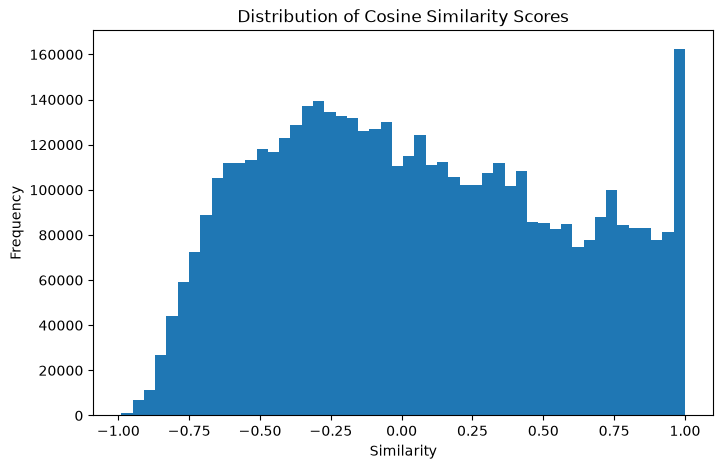

In [65]:
# Similarity Distribution Analysis
import matplotlib.pyplot as plt

scores = similarity_matrix.flatten()

plt.figure(figsize=(8,5))
plt.hist(scores, bins=50)
plt.title("Distribution of Cosine Similarity Scores")
plt.xlabel("Similarity")
plt.ylabel("Frequency")
plt.show()

## 12. Inspecting the recommendations
### Spot-Check Recommendations:
Run the recommender on another specific seed track to manually review whether the suggested songs make intuitive sense.

In [66]:
# Inspecting the recommendations
recommend_songs(
    "flo milli - flo jackson",
    similarity_matrix,
    tracks_df,
    track_lookup
)

,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
1549,BOLO (feat. YDG),PENOMECO,0.990974,0.419805,0.044444,0.023593,1,True
1540,M a k e I t T o T h e M o r n i n g,PARTYNEXTDOOR,0.944109,0.375021,0.044444,0.001049,1,True
2149,Chai ya saa kumi,Ywaya Tajiri,0.886855,0.511262,0.222222,0.147123,1,True
754,Baby Now That I Found You,Ella Bright,0.878954,0.268422,0.044444,0.018058,0,True
1868,Dick (feat. Doja Cat),StarBoi3,0.877525,0.478925,0.177778,0.075053,1,True
2110,No Hands (feat. Roscoe Dash & Wale),Waka Flocka Flame,0.869542,0.477593,0.155556,0.092593,1,True
2148,Spend Dat,Yung Miami,0.867388,0.441956,0.088889,0.043379,1,True
367,NORMAL,BTS,0.855769,0.456304,0.155556,0.075022,1,True
567,Sex Talk,D4M $loan,0.851941,0.596922,0.111111,0.032133,2,True
739,Only You,Ebony Riley,0.841975,0.334810,0.044444,0.018228,1,True


In [70]:
recommend_songs(
    "jung kook - standing next to you",
    similarity_matrix,
    tracks_df,
    track_lookup
)

,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
2159,PILLOWTALK,ZAYN,0.993528,0.761185,0.333333,0.184665,3,False
1717,APT.,ROSÉ,0.991343,0.730884,0.333333,0.165660,3,False
1955,Blank Space,Taylor Swift,0.990327,0.568245,0.266667,0.145800,2,False
1973,You Belong With Me (Taylor’s Version),Taylor Swift,0.989215,0.530869,0.222222,0.144234,2,False
1571,Eyes Off You,PRETTYMUCH,0.987429,0.799685,0.422222,0.210925,3,False
1180,I Like Me Better,LAUV,0.987359,0.994346,0.511111,0.265125,4,False
960,Constellations,Jade LeMac,0.986743,0.716395,0.266667,0.151587,3,False
1205,MUTT (feat. Chris Brown) [CB REMIX],Leon Thomas,0.986482,0.543557,0.244444,0.137500,2,False
695,Agora Hills,Doja Cat,0.981904,0.812265,0.422222,0.261246,3,False
1927,Saturn,SZA,0.979463,0.526595,0.244444,0.096026,2,False


In [68]:
recommend_songs(
    "yung miami - spend dat",
    similarity_matrix,
    tracks_df,
    track_lookup
)

,track_name,artist_name,similarity_score,preference_score,play_count,total_minutes_played,playlist_count,in_library
963,Empty Space,James Arthur,0.934655,0.275081,0.066667,0.026770,0,True
1549,BOLO (feat. YDG),PENOMECO,0.884875,0.419805,0.044444,0.023593,1,True
1540,M a k e I t T o T h e M o r n i n g,PARTYNEXTDOOR,0.871845,0.375021,0.044444,0.001049,1,True
820,Flo Jackson,Flo Milli,0.867388,0.438674,0.088889,0.038491,1,True
2149,Chai ya saa kumi,Ywaya Tajiri,0.847563,0.511262,0.222222,0.147123,1,True
754,Baby Now That I Found You,Ella Bright,0.824997,0.268422,0.044444,0.018058,0,True
1760,Walk Em Like a Dog,Saucy Santana,0.819951,0.303125,0.066667,0.013124,1,False
739,Only You,Ebony Riley,0.804343,0.334810,0.044444,0.018228,1,True
568,Swagg Talk,D4M $loan,0.800588,0.351639,0.155556,0.051415,1,False
1939,Guilty,TAEMIN,0.792878,0.274661,0.066667,0.014652,1,False


## 13. Save Model
### Save the Trained Artifacts
Persist the similarity matrix, track lookup, tracks DataFrame and fitted scaler to disk using `joblib`, so the recommendation engine can be reloaded later (e.g. in the Streamlit app) without re-running all the feature engineering and similarity computation from scratch.

In [ ]:
# Save Model 
import joblib

joblib.dump(similarity_matrix, "models\\similarity_matrix.pkl")
joblib.dump(track_lookup, "models\\track_lookup.pkl")
joblib.dump(tracks_df, "models\\tracks_df.pkl")
joblib.dump(scaler, "models\\scaler.pkl")

['C:\\Users\\class\\OneDrive\\Documents\\Spotify Recommendation System\\models\\scaler.pkl']